In [1]:
library(MLmetrics)
library(randomForest)
library(dplyr)

ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

Warning message:
"le package 'MLmetrics' a été compilé avec la version R 4.2.3"

Attachement du package : 'MLmetrics'


L'objet suivant est masqué depuis 'package:base':

    Recall


Warning message:
"le package 'randomForest' a été compilé avec la version R 4.2.3"
randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.

Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


L'objet suivant est masqué depuis 'package:randomForest':

    combine


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union




In [2]:
datam<-read.csv("data_target_encoding.csv",stringsAsFactors = T)
test<-read.csv("test_target_encoding.csv",stringsAsFactors = T)

In [3]:
set.seed(2)
n_trees <- 500
nfeat <- ncol(datam)-1 #I remove 1 to remove damage_grade
m_tries <- c(floor(0.5*sqrt(nfeat)))
nrows<-nrow(datam)
target_variable <- match('damage_grade', colnames(datam))

model <- randomForest(x=datam[,-c(target_variable)],
                    y=as.factor(datam[,c(target_variable)]),
                    ntree=n_trees,mtry=m_tries,keep.forest=TRUE,importance=TRUE)
yhat<-predict(model,test[,-c(target_variable)])

In [4]:
submission<-read.csv("submission_format.csv",stringsAsFactors = T)

In [5]:
submission[,2]<-as.integer(yhat)

In [6]:
write.csv(submission,'submission_test_RF_1000.csv',col.names=TRUE,row.names=FALSE)

Warning message in write.csv(submission, "submission_test_RF_1000.csv", col.names = TRUE, :
"une tentative de modification de 'col.names' a échoué"


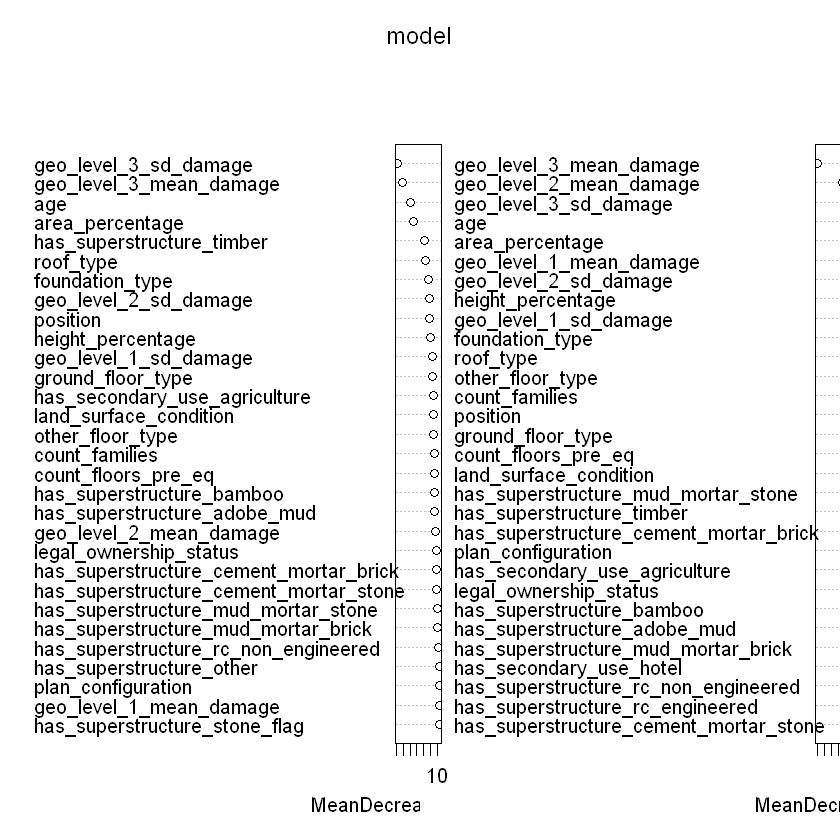

In [3]:
set.seed(2)
n_trees <- 20
nfeat <- ncol(datam)-1 #I remove 1 to remove damage_grade
nrows<-nrow(datam)
target_variable <- match('damage_grade', colnames(datam))

model <- randomForest(x=datam[,-c(target_variable)],
                    y=as.factor(datam[,c(target_variable)]),
                    ntree=n_trees,keep.forest=TRUE,importance=TRUE)

varImpPlot(model)
 

In [5]:
model$importance

,1,2,3,MeanDecreaseAccuracy,MeanDecreaseGini
geo_level_1_mean_damage,4.571592e-02,2.531837e-02,1.892981e-02,2.514385e-02,6542.453432
geo_level_1_sd_damage,2.293611e-02,1.589546e-02,1.103836e-02,1.494901e-02,3892.916670
geo_level_2_mean_damage,7.041352e-02,3.652240e-02,3.925252e-02,4.069978e-02,12144.966990
geo_level_2_sd_damage,1.925438e-02,2.319464e-02,1.760187e-02,2.094044e-02,6243.064909
geo_level_3_mean_damage,1.940156e-01,1.141605e-01,2.356706e-01,1.624835e-01,30038.379358
geo_level_3_sd_damage,5.773214e-02,4.638614e-02,2.953680e-02,4.184995e-02,10901.629680
count_floors_pre_eq,1.014332e-02,9.781898e-03,3.541762e-03,7.728363e-03,1595.061776
age,5.884711e-02,2.953527e-03,1.060576e-02,1.089853e-02,7570.466628
area_percentage,8.073616e-03,1.188028e-02,7.733395e-03,1.012834e-02,7077.145543
height_percentage,1.308397e-02,1.332089e-02,6.583967e-03,1.104496e-02,4008.137183


In [7]:
options(repr.plot.width=31, repr.plot.height=9)

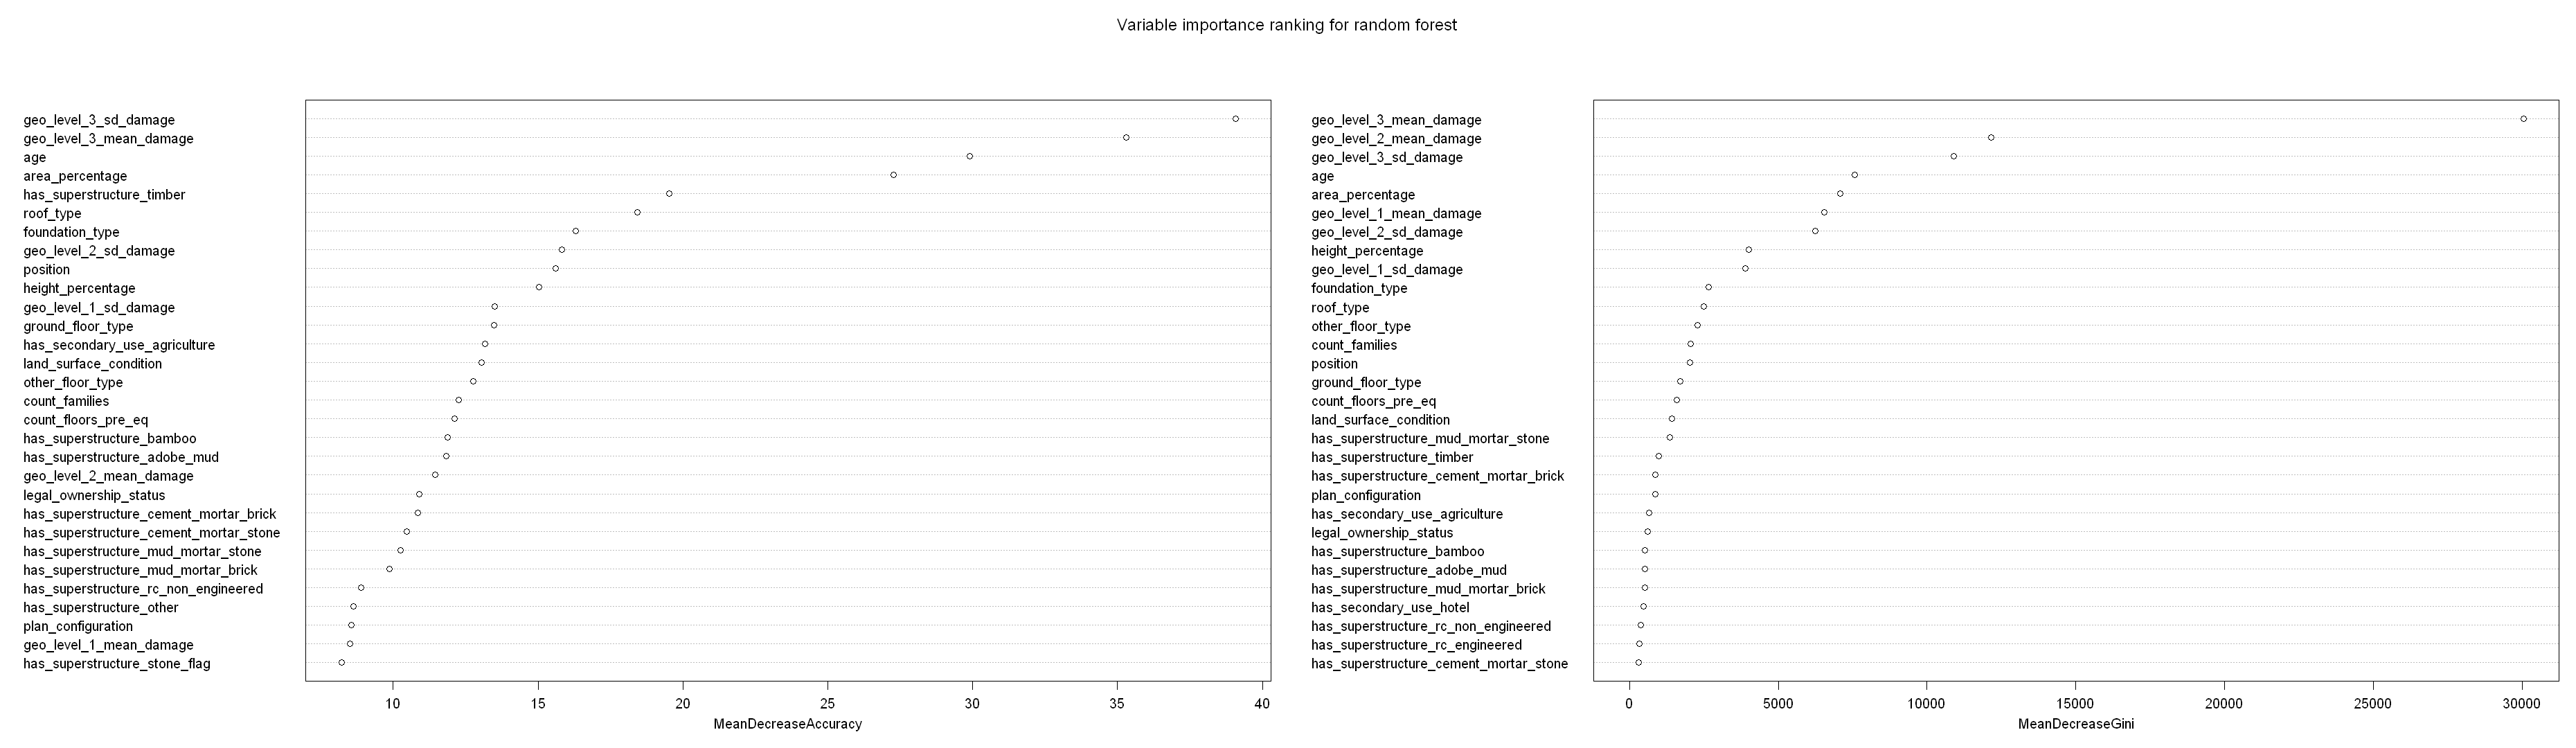

In [9]:
varImpPlot(model,main='Variable importance ranking for random forest')